In [9]:
import pandas as pd
import numpy as np

In [10]:
# Define the column names for the DataFrame
col_names = ['id', 'mol', 'type', 'q', 'x', 'y', 'z', 'ix', 'iy', 'iz']

# Read the data from the file and store it in a list of lists
data = []
with open('H2_trajectories/300PS.lammpstrj') as f:
    lines = f.readlines()
    xlo, ylo, zlo = [float(l.split()[0]) for l in lines[5:8]]
    xhi, yhi, zhi = [float(l.split()[1]) for l in lines[5:8]]
    L = xhi-xlo
    for i in range(len(lines)):
        if 'ITEM: TIMESTEP' in lines[i]:
            timestep = int(lines[i+1])
            if timestep > 1001000:
                break  # Exit the loop if timestep > 1001000
            num_particles = int(lines[i+3].split()[0])
            for j in range(i+9, i+9+num_particles):
                line = lines[j]
                particle_id, mol, particle_type, q, x, y, z, ix, iy, iz = line.split()
                data.append([timestep, particle_id, mol, particle_type, q, x, y, z, ix, iy, iz])

# Convert the list of lists to a DataFrame
df = pd.DataFrame(data, columns=['time'] + col_names)

# Convert the data types of some columns to float
df[['q', 'x', 'y', 'z']] = df[['q', 'x', 'y', 'z']].astype(float)
df[['id','mol','type', 'ix', 'iy', 'iz']] = df[['id','mol','type', 'ix', 'iy', 'iz']].astype(int)
df[['time']] = df[['time']].astype(float)
df['time']= df['time']/1000
df


,time,id,mol,type,q,x,y,z,ix,iy,iz
0,0.0,1,21,21,0.0,0.324798,0.275393,0.463235,0,0,0
1,0.0,2,21,21,0.0,0.326724,0.269790,0.456940,0,0,0
2,0.0,3,22,21,0.0,0.418277,0.025537,0.227619,0,0,0
3,0.0,4,22,21,0.0,0.419378,0.023669,0.236007,0,0,0
4,0.0,5,23,21,0.0,0.937598,0.676785,0.722087,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
999995,1001.0,996,518,21,0.0,0.665668,0.379667,0.194355,0,0,0
999996,1001.0,997,519,21,0.0,0.415654,0.227438,0.881797,0,0,0
999997,1001.0,998,519,21,0.0,0.415750,0.235596,0.881882,0,0,0
999998,1001.0,999,520,21,0.0,0.346457,0.397502,0.777960,0,0,0


In [11]:
len(df)
print(L)
df

88.361514


,time,id,mol,type,q,x,y,z,ix,iy,iz
0,0.0,1,21,21,0.0,0.324798,0.275393,0.463235,0,0,0
1,0.0,2,21,21,0.0,0.326724,0.269790,0.456940,0,0,0
2,0.0,3,22,21,0.0,0.418277,0.025537,0.227619,0,0,0
3,0.0,4,22,21,0.0,0.419378,0.023669,0.236007,0,0,0
4,0.0,5,23,21,0.0,0.937598,0.676785,0.722087,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
999995,1001.0,996,518,21,0.0,0.665668,0.379667,0.194355,0,0,0
999996,1001.0,997,519,21,0.0,0.415654,0.227438,0.881797,0,0,0
999997,1001.0,998,519,21,0.0,0.415750,0.235596,0.881882,0,0,0
999998,1001.0,999,520,21,0.0,0.346457,0.397502,0.777960,0,0,0


In [12]:

df['xu'] = df['x']*L
df['yu'] = df['y']*L
df['zu'] = df['z']*L
df['xa'] = df['xu']+df['xu']*df['ix'].astype(float)
df['ya'] = df['yu']+df['yu']*df['iy'].astype(float)
df['za'] = df['zu']+df['zu']*df['iz'].astype(float)
df


,time,id,mol,type,q,x,y,z,ix,iy,iz,xu,yu,zu,xa,ya,za
0,0.0,1,21,21,0.0,0.324798,0.275393,0.463235,0,0,0,28.699643,24.334142,40.932146,28.699643,24.334142,40.932146
1,0.0,2,21,21,0.0,0.326724,0.269790,0.456940,0,0,0,28.869827,23.839053,40.375910,28.869827,23.839053,40.375910
2,0.0,3,22,21,0.0,0.418277,0.025537,0.227619,0,0,0,36.959589,2.256461,20.112759,36.959589,2.256461,20.112759
3,0.0,4,22,21,0.0,0.419378,0.023669,0.236007,0,0,0,37.056875,2.091446,20.853936,37.056875,2.091446,20.853936
4,0.0,5,23,21,0.0,0.937598,0.676785,0.722087,0,0,0,82.847579,59.801747,63.804701,82.847579,59.801747,63.804701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1001.0,996,518,21,0.0,0.665668,0.379667,0.194355,0,0,0,58.819432,33.547951,17.173502,58.819432,33.547951,17.173502
999996,1001.0,997,519,21,0.0,0.415654,0.227438,0.881797,0,0,0,36.727817,20.096766,77.916918,36.727817,20.096766,77.916918
999997,1001.0,998,519,21,0.0,0.415750,0.235596,0.881882,0,0,0,36.736299,20.817619,77.924429,36.736299,20.817619,77.924429
999998,1001.0,999,520,21,0.0,0.346457,0.397502,0.777960,0,0,0,30.613465,35.123879,68.741723,30.613465,35.123879,68.741723


In [13]:
print(len(df))
print(num_particles)
print(int(len(df)/num_particles-1))

1000000
1000
999


In [14]:
R1_list=[]
size=[]
# dx_list =[]
# dy_list =[]
# dz_list =[]

for i in range(int(len(df)/num_particles-1)):
    dx = df[df.time == i+1]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+1]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+1]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R1_list.append(dr)


    
R10_list=[]

for i in range(int(len(df)/num_particles-10)):
    dx = df[df.time == i+10]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+10]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+10]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R10_list.append(dr)
    size.append(i)
    
R100_list=[]

for i in range(int(len(df)/num_particles-100)):
    dx = df[df.time == i+100]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+100]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+100]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R100_list.append(dr)




In [17]:
R1_resultList = []
R10_resultList =[]
R100_resultList =[]

# Traversing in till the length of the input list of lists
for m in range(len(R1_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R1_list[m])):

      # Add each element to the result list
      R1_resultList.append(R1_list[m][n])
        
for m in range(len(R10_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R10_list[m])):

      # Add each element to the result list
      R10_resultList.append(R10_list[m][n])
        
for m in range(len(R100_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R100_list[m])):

      # Add each element to the result list
      R100_resultList.append(R100_list[m][n])
        

print(R1_resultList[0:5])
print(R10_resultList[0:5])

[array([0.83883297]), array([1.71297791]), array([6.62779856]), array([7.19673639]), array([0.92352385])]
[array([5.2281054]), array([4.47806402]), array([4.63921425]), array([4.40455224]), array([11.84598755])]


/Users/alotmi.m/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Users/alotmi.m/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Users/alotmi.m/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexib

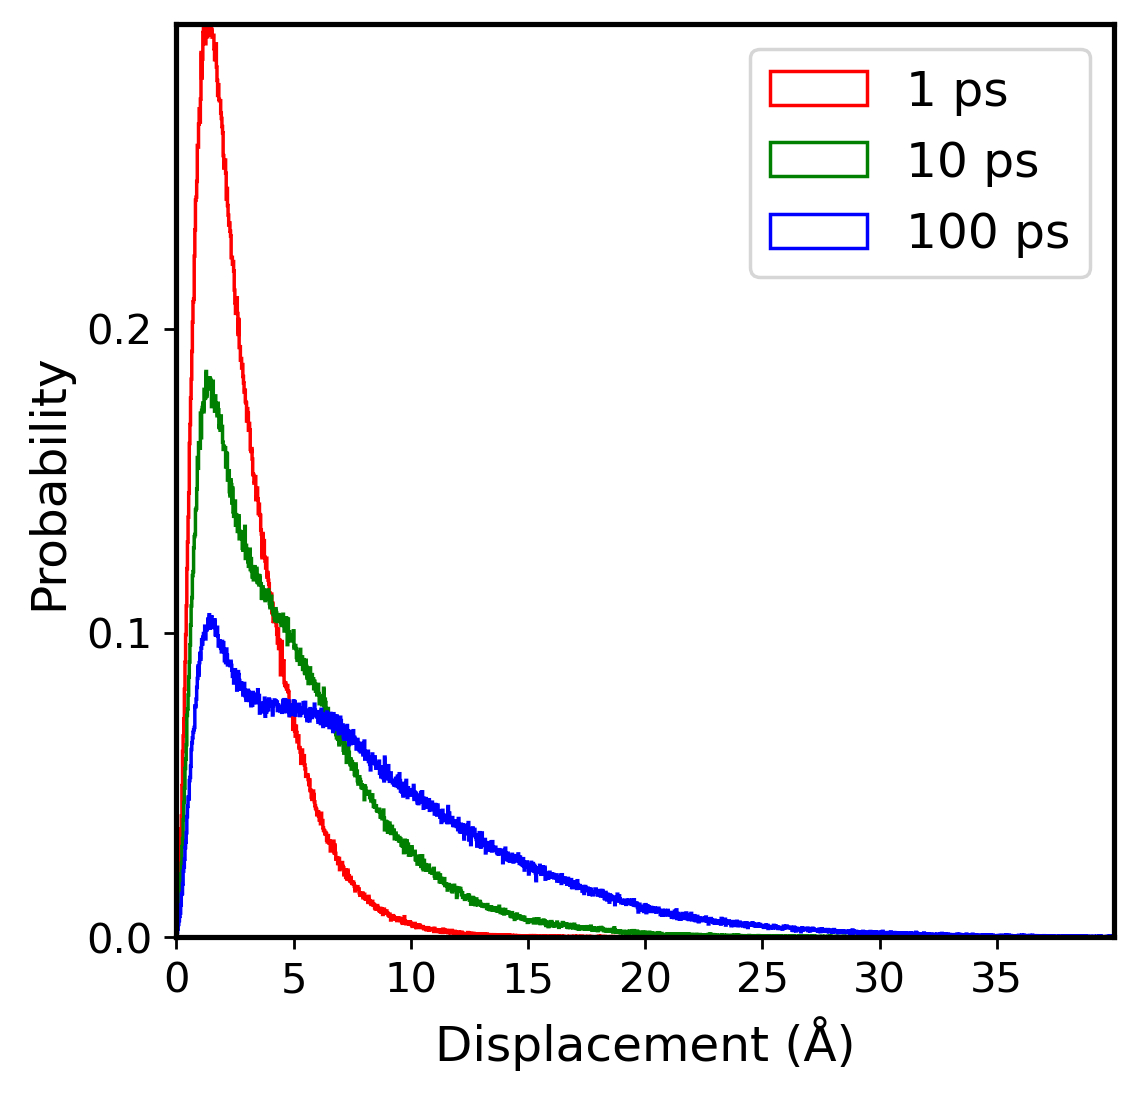

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(5,5),dpi=250)

# plt.title("PS 500K")
bins = np.linspace(-2,40,1600)

sns.distplot(R1_resultList,label = "1 ps",bins=bins,color='red', hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "r"}, kde_kws={"linewidth":0})
sns.distplot(R10_resultList,label = "10 ps",bins=bins,kde=True,color='green',hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "g"},kde_kws={"linewidth":0})
sns.distplot(R100_resultList,label = "100 ps",bins=bins,kde=True,color='blue',hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "b"},kde_kws={"linewidth":0})


plt.xlim([0,40])
plt.ylim([0,0.3])
plt.xticks(np.arange(0, 40, 5), fontsize=12)
plt.yticks(np.arange(0, 0.3, 0.1), fontsize=12)

plt.xlabel("Displacement (Å)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(fontsize=14)
plt.subplots_adjust(left=0.15, bottom=0.15)


plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['top'].set_linewidth(1.5)


plt.show()

# 